In [1]:
import pandas as pd
from neutrophil_shape.config.loader import load_config
from neutrophil_shape.CustomFunctions import DetailedBalance, utils

In [2]:
### load config stuff
config = load_config(microscope_type = 'lls')
#set alignment
config._alignment = 'trajectory'
savedir = config.common.savedir
datadir = savedir / 'shape_data'
dbdir = savedir / 'detailed_balance'
ntrans = config.db_params.ntrans
origins = config.db_params.origins
pc_combos = config.common.pc_combos
####### load common directories and data
FullFrame = pd.read_csv(datadir.joinpath('All_Data_with_CGPS_bins.csv'), index_col=0)
centers = pd.read_csv(datadir.joinpath('PC_bin_centers.csv'), index_col=0)

## restrict the treatments and PCs specifically for bootstrapping
bstreats = ['Random']
bspcs = [(1,2),(4,5),(2,8)]
alldatabs = False

In [9]:
############# create all CGPSs #############
for whichpcs in pc_combos:
    #pass if we want to restrict PCs
    if len(bspcs)>0 and whichpcs not in bspcs:
        continue
    if __name__ ==  '__main__':
        ########### get raw transitions and pairs ###########
        rawtrans = DetailedBalance.get_raw_cgps_trajectories(
                FullFrame, #pandas dataframe with all of the cgps binned data
                whichpcs, #which two PCs to use in the cgps [x,y]
                config,
                )

        ########### interpolate all transitions so that only individual transitions are made ###########
        transdf_sep = DetailedBalance.get_interpolated_cgps_trajectories(
                rawtrans, #pandas dataframe with all of the cgps binned data
                whichpcs, #which two PCs to use in the cgps [x,y]
                config,
                )

        ############## get the counts of cells leaving 
        trans_rate_df_sep = DetailedBalance.aggregate_transition_counts(
                transdf_sep, #transdf_sep from get_interpolated_cgps_trajectories
                whichpcs, #which two PCs to use in the cgps [x,y]
                config,
                )

Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 459.240451478778 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 470.70831059711037 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 471.44039293708107 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 467.02909595224264 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 463.18825200336204 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 463.9920107006465 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
To

In [ ]:
############# measure aer and cycling frequencies from the observed raw data ###########

for whichpcs in pc_combos:
    #pass if we want to restrict PCs
    if len(bspcs)>0 and whichpcs not in bspcs:
        continue
    #add specific scaling
    xyscaling = [centers[f'PC{whichpcs[0]}'].diff().mean(),centers[f'PC{whichpcs[1]}'].diff().mean()]
    #set the origin to the actual center
    origin = origins[pc_combos.index(whichpcs)]

    ### open the raw transitions
    rawtrans = pd.read_csv(dbdir.joinpath(
            f'PC{whichpcs[0]}-PC{whichpcs[1]}_transitions_separated.csv'), index_col=0)

    #get the area scaling in x and y based on the size of the bins in the cgps
    results = []
    for i, cell in rawtrans.groupby('CellID'):
        #sort data and get continuous transitions in order
        cell, runs = utils.get_consecutive_transitions(cell)
        #measure aer and cycling frequencies for each run of transitions and add to results
        for r in runs:
            c = cell.iloc[r].reset_index(drop=True)
            results.append(DetailedBalance.get_area_enclosing_rate((
                c,
                config.db_params.nbins,
                xyscaling,
                origin,
                )))

    #make a dataframe and save it
    allaers = pd.concat(results, ignore_index = True)
    allaers.to_csv(dbdir.joinpath(
                    f'PC{whichpcs[0]}-PC{whichpcs[1]}_raw_transition_aer_cf.csv'))



In [ ]:
########### bootstrap transitions and calculate all the aers and cfs around all the pairwise cgps ###############
for whichpcs in pc_combos:
    #pass if we want to restrict PCs
    if len(bspcs)>0 and whichpcs not in bspcs:
        continue
    ## use a separate savedir to bootstrap using all data
    bssavestr = 'alldatabs' if alldatabs else 'separatedatabs'

    if __name__ ==  '__main__':
        #### open the transitions
        rawtrans = pd.read_csv(dbdir.joinpath(
            f'PC{whichpcs[0]}-PC{whichpcs[1]}_transitions_separated.csv'), index_col=0)

        #merge all treatments if bootstrapping with all data
        if alldatabs:
            rawtrans.loc[:,'Treatment'] = 'alldata'

        #restrict to bootstrapped treatments if desired
        if len(bstreats)>0:
            rawtrans = rawtrans[rawtrans.Treatment.isin(bstreats)]


        ############## BOOTSTRAP MANY TRAJECTORIES ##########
        bstrans, bsint, bsframe_sep_full = DetailedBalance.get_bootstrapped_cgps_trajectories(
                rawtrans, #raw transition pairs from get_raw_cgps_trajectories
                whichpcs, #which two PCs to use in the cgps [x,y]
                config,
                bssavestr, #where to save the bootstrapped dataframes
                )


        ############# open average bootstrapped currents ###################
        bsfield_sep = DetailedBalance.get_avg_current_error(
                bsframe_sep_full, #transition rates in the cgps from get_bootstrapped_cgps_trajectories
                whichpcs, #which two PCs to use in the cgps [x,y]
                config,    
                bssavestr, #where to save the aggregated counts
                )


        ############# measure aer and cycling frequencies ###########
        DetailedBalance.get_aer_cf(
            bstrans,
            whichpcs, #which two PCs to use in the cgps [x,y]
            config,
            bssavestr, #where to save calculated aers and cfs
            )


        ##### boostrap gaps in bootstrapped trajectories
        DetailedBalance.get_lls_gapped_bootstrap(
            whichpcs,
            config,
            )



Average track run length mean for real data is 36.45230830830676 and mean gap frequency is 0.004860890683464839)


c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Average track run length mean for bootstrapped data is 37.31830280484355 and mean gap frequency is 0.0044403676159448695)


100%|██████████| 3000/3000 [00:36<00:00, 82.19it/s] 


Average track run length mean for real data is 35.098037075215316 and mean gap frequency is 0.004887134341111721)


...

100%|██████████| 3000/3000 [00:37<00:00, 80.64it/s] 


Average track run length mean for real data is 34.37504726955192 and mean gap frequency is 0.004885727027352138)


c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Average track run length mean for bootstrapped data is 34.839974858328496 and mean gap frequency is 0.004384992285394803)


100%|██████████| 3000/3000 [00:37<00:00, 79.47it/s] 


c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Aaron\.conda\envs\nsa\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = 

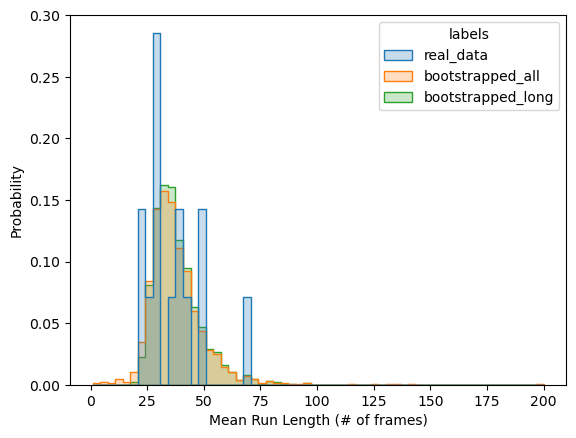

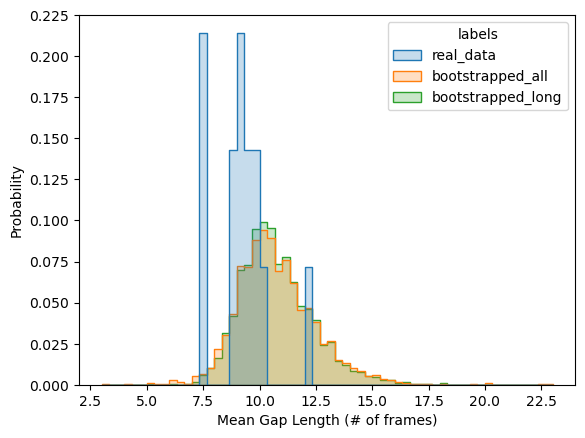

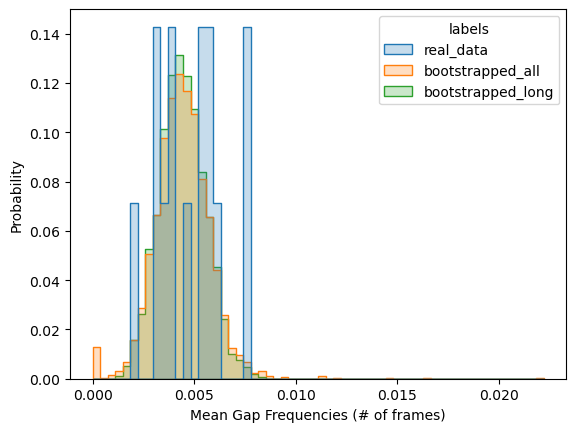

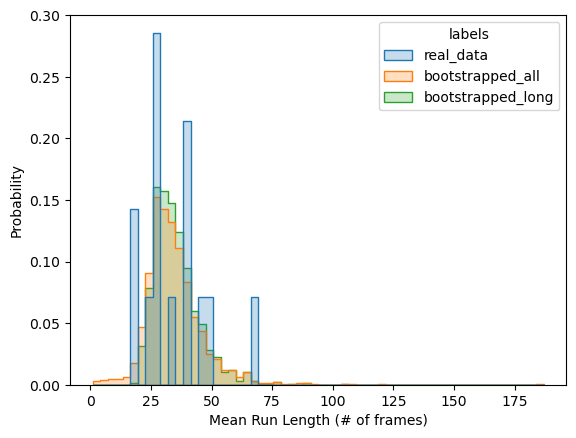

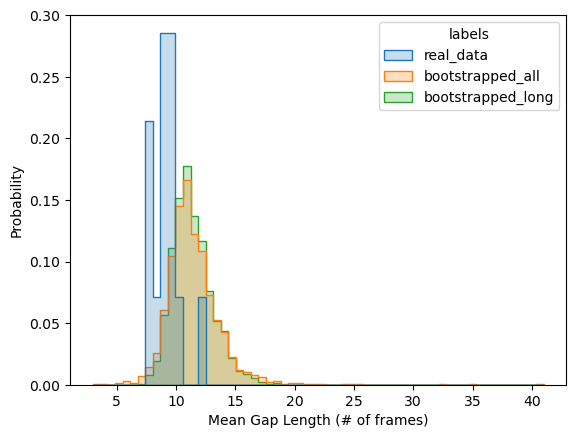

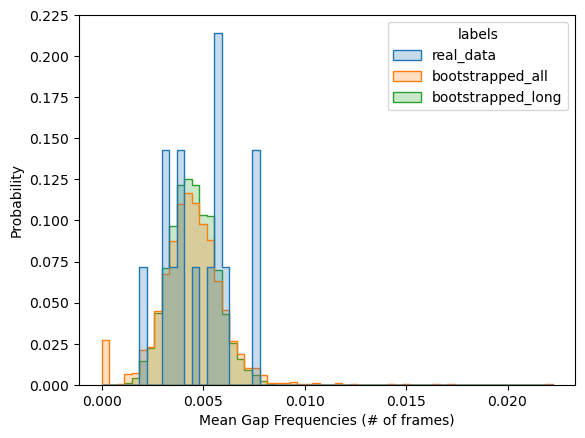

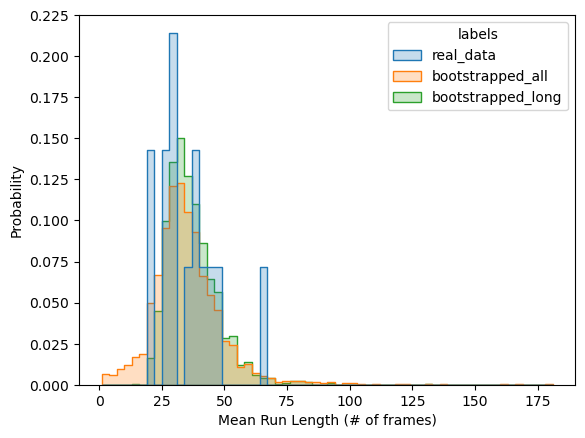

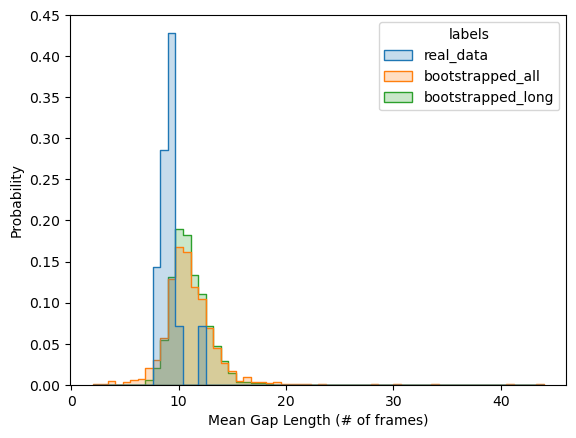

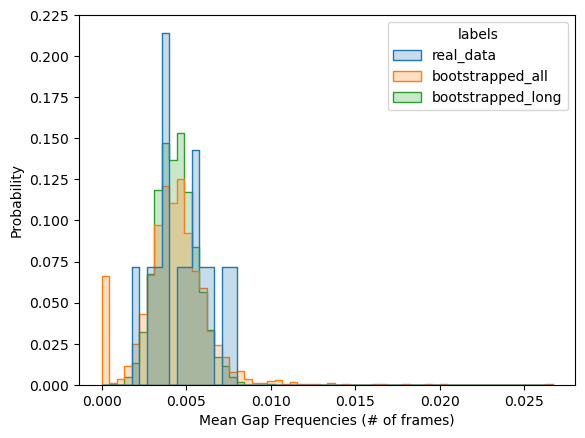

In [17]:
############ PLOT THE DISTRIBUTIONS OF REAL AND BOOTSTRAPPED GAPS AND RUNS ############
import matplotlib.pyplot as plt
import seaborn as sns


for whichpcs in bspcs:
        justaers = pd.read_csv(dbdir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_raw_transition_aer_cf.csv'), index_col = 0)
        FullFrame['real_time'] = FullFrame.time.copy()
        realcelldf = FullFrame.merge(justaers[['CellID','aer','real_time','cumulative_time','time_elapsed']],
                                on = ['CellID','real_time'], how = 'left')

        ########## measure gap frequency and duration
        allrunlengths, allrunlengthmeans, allgaplengths, allgaplengthmeans, allgapfrequencies = DetailedBalance.get_run_stats(
                realcelldf, #dataframe
                'CellID', #what is the identifier to group by as a str
                config, #frame rate of the data
                )

        #### get bs data with gaps
        bsaers = pd.read_csv(dbbsdir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_bootstrapped_{ntrans}_Area_Enclosing_Rates.csv'), index_col=0)
        bs_with_gaps = pd.read_csv(dbbsdir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_bootstrapped_{ntrans}_Area_Enclosing_Rates_gaps.csv'), index_col=0)

        ### measure the gap probability in the newly gapped bootstrap data
        #change real_time to just time
        bs_gap_measure = bs_with_gaps.merge(bsaers[['iter','real_time','cumulative_time','time_elapsed']], on = ['iter','real_time'], how = 'left')
        #add dummy column
        bs_gap_measure['aer'] = 0
        bsallrunlengths, bsallrunlengthmeans, bsallgaplengths, bsallgaplengthmeans, bsallgapfrequencies = DetailedBalance.get_run_stats(
                bs_gap_measure, #dataframe
                'iter', #what is the identifier to group by as a str
                config, #frame rate of the data
                )

        ############ limit bootstrapped data to long iterations only
        longiters = bs_with_gaps.iter.value_counts()>realcelldf[~realcelldf.aer.isna()].CellID.value_counts().min()
        longbs = bs_gap_measure[bs_gap_measure.iter.isin(longiters[longiters==True].index.to_list())]
        #add dummy column
        longbs['aer'] = 0
        bsallrunlengthslong, bsallrunlengthmeanslong, bsallgaplengthslong, bsallgaplengthmeanslong, bsallgapfrequencieslong = DetailedBalance.get_run_stats(
                longbs, #dataframe
                'iter', #what is the identifier to group by as a str
                config, #frame rate of the data
                )


        ################ PLOT THE REAL AND BOOTSTRAPPED DISTRIBUTIONS FOR 
        ################ VARIOUS RUN AND GAP STATS 
        ################ 
        labels = ['real_data','bootstrapped_all','bootstrapped_long']


        ############## run lengths
        data = [allrunlengthmeans,bsallrunlengthmeans,bsallrunlengthmeanslong]
        all_labels = [[labels[i]]*len(x) for i, x in enumerate(data)]
        tempdf = pd.DataFrame({
                'labels': np.concatenate(all_labels),
                'data': np.concatenate(data)
                })

        fig, ax = plt.subplots()
        sns.histplot(data = tempdf, x = 'data', hue = 'labels', bins = 60, stat = 'probability',
                element = 'step', common_norm = False, ax = ax)
        ax.set_xlabel('Mean Run Length (# of frames)')
        plt.savefig(dbbsdir.joinpath('bootstrapped_data_gap_qc_mean_run_lengths.png'))



        ############## gap lengths
        data = [allgaplengthmeans,bsallgaplengthmeans,bsallgaplengthmeanslong]
        all_labels = [[labels[i]]*len(x) for i, x in enumerate(data)]
        tempdf = pd.DataFrame({
                'labels': np.concatenate(all_labels),
                'data': np.concatenate(data)
                })

        fig, ax = plt.subplots()
        sns.histplot(data = tempdf, x = 'data', hue = 'labels', bins = 60, stat = 'probability',
                element = 'step', common_norm = False, ax = ax)
        ax.set_xlabel('Mean Gap Length (# of frames)')
        plt.savefig(dbbsdir.joinpath('bootstrapped_data_gap_qc_mean_gap_lengths.png'))


        ############## gap frequencies
        data = [allgapfrequencies,bsallgapfrequencies,bsallgapfrequencieslong]
        all_labels = [[labels[i]]*len(x) for i, x in enumerate(data)]
        tempdf = pd.DataFrame({
                'labels': np.concatenate(all_labels),
                'data': np.concatenate(data)
                })

        fig, ax = plt.subplots()
        sns.histplot(data = tempdf, x = 'data', hue = 'labels', bins = 60, stat = 'probability',
                element = 'step', common_norm = False, ax = ax)
        ax.set_xlabel('Mean Gap Frequencies (# of frames)')
        plt.savefig(dbbsdir.joinpath('bootstrapped_data_gap_qc_mean_gap_frequencies.png'))